# Control plots for measurements on BGS mocks

## 0- Setup

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from acm.utils.default import cosmo_list
from plot_utils import load_hod_params, plot_hod_histogram, plot_hod_triangle

In [2]:
parameters_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/parameters/')
measurements_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/measurements/')
dr2_dir = Path('/pscratch/sd/s/sbouchar/DR2_BGS/measurements/')
sg_dir = Path('/pscratch/sd/s/sbouchar/SecondGen/CubicBox/BGS/z0.200/AbacusSummit_base_c000_ph000/measurements/Mr-20') # SecondGen measurements directory
bgs_nofilter_dir = Path('/pscratch/sd/s/sbouchar/test/bgs_nofilter/base/c000_ph000/seed0/') # Temporary, to test density filtering

phase_list = None # TODO: define phases

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.show()

## 1- Parameter sampling

### 1.1- Cosmological parameters
See [AbacusSummit](https://abacussummit.readthedocs.io/en/latest/cosmologies.html) cosmologies for details.

### 1.2- HOD parameters

#### Compare sampling for BGS and EMC

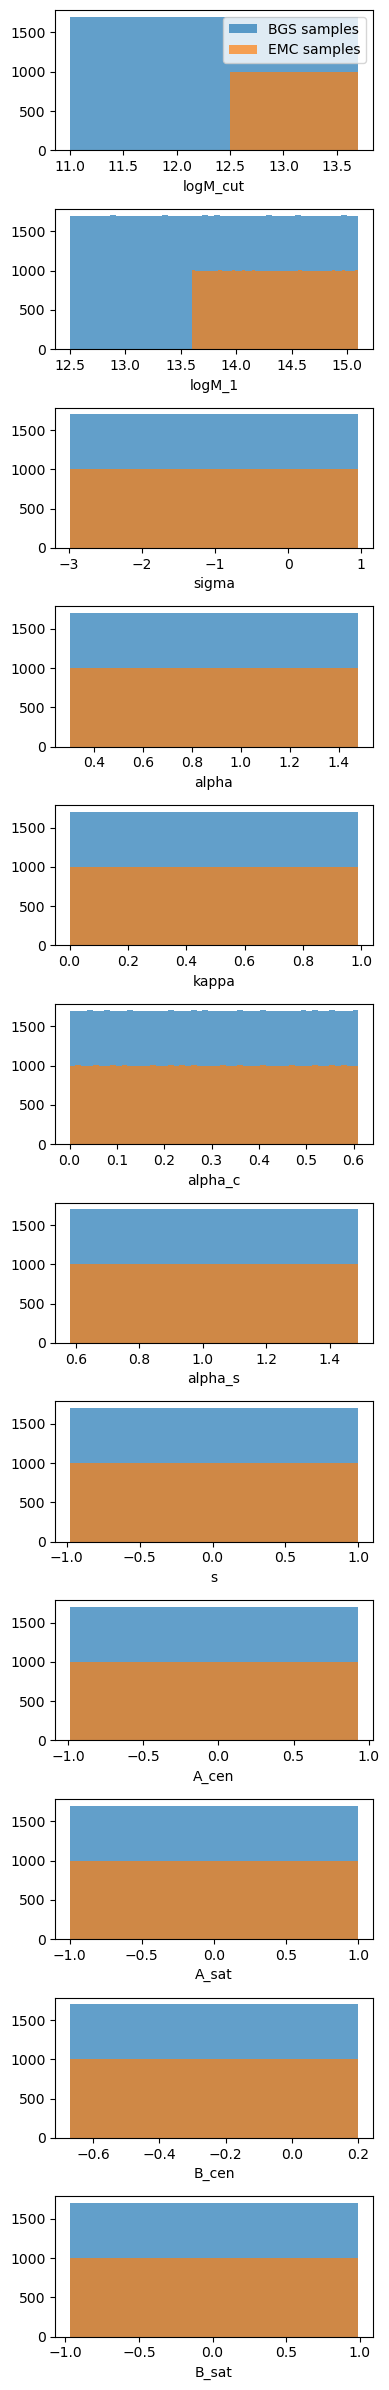

In [4]:
hod_params_bgs = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_bgs = np.concatenate([hod_params_bgs[key] for key in sorted(hod_params_bgs.keys())])

hod_params_emc = load_hod_params('/pscratch/sd/e/epaillas/emc/hod_params/yuan23/cosmo_split/')
hod_params_emc = np.concatenate([hod_params_emc[key] for key in sorted(hod_params_emc.keys())])

fig, ax = plot_hod_histogram(
    hods = [hod_params_bgs, hod_params_emc], 
    parameters=hod_params_bgs.dtype.names, 
    labels=['BGS samples', 'EMC samples'], 
    bins=50, 
    alpha=0.7, 
    # density=True,
)
ax[0].legend()
fig.tight_layout()

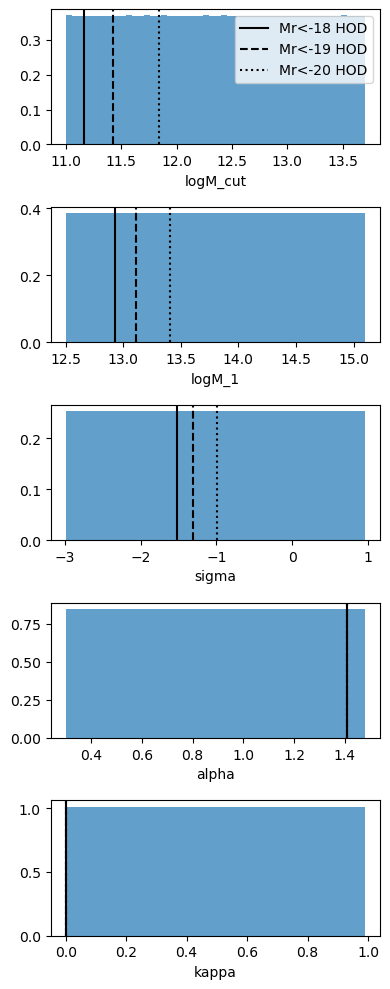

In [5]:
hod_params_bgs = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_bgs = np.concatenate([hod_params_bgs[key] for key in sorted(hod_params_bgs.keys())])

params = ['logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa']
fig, ax = plot_hod_histogram(
    hods = [hod_params_bgs,], 
    parameters=params, 
    labels=['BGS samples'], 
    bins=50, 
    alpha=0.7, 
    density=True,
)

HOD_params = dict(
    Mr18 = dict(
        logM_cut = 11.16745, 
        logM_1 = 12.92566, 
        kappa = 10**(5.08046 - 11.16745),  # kappa = M0/Mcut = 10^(logM0 - logMcut)
        sigma = np.log10(0.02969), 
        alpha = 1.40723
    ),
    Mr19 = dict(
        logM_cut = 11.42954, 
        logM_1 = 13.10684, 
        kappa = 10**(7.16418 - 11.42954), # kappa = M0/Mcut = 10^(logM0 - logMcut)
        sigma = np.log10(0.04897), 
        alpha = 1.40762,
    ),
    Mr20 = dict(
        logM_cut = 11.84549, 
        logM_1 = 13.40267, 
        kappa = 10**(9.24791-11.84549), # kappa = M0/Mcut = 10^(logM0 - logMcut) 
        sigma = np.log10(0.10304), # Passing logsigma to BoxHOD 
        alpha = 1.41008
    )
)

ls = ['-', '--', ':']
for i, Mr in enumerate([-18, -19, -20]):
    for j, key in enumerate(params):
        ax[j].axvline(HOD_params[f'Mr{abs(Mr)}'][key], color='k', linestyle=ls[i])

handles = []
for i, Mr in enumerate([-18, -19, -20]):
    handle = plt.Line2D([], [], color='k', linestyle=ls[i], label=f'Mr<{Mr} HOD')
    handles.append(handle)

ax[0].legend(handles=handles)
fig.tight_layout()

#### Compare cosmologies for BGS

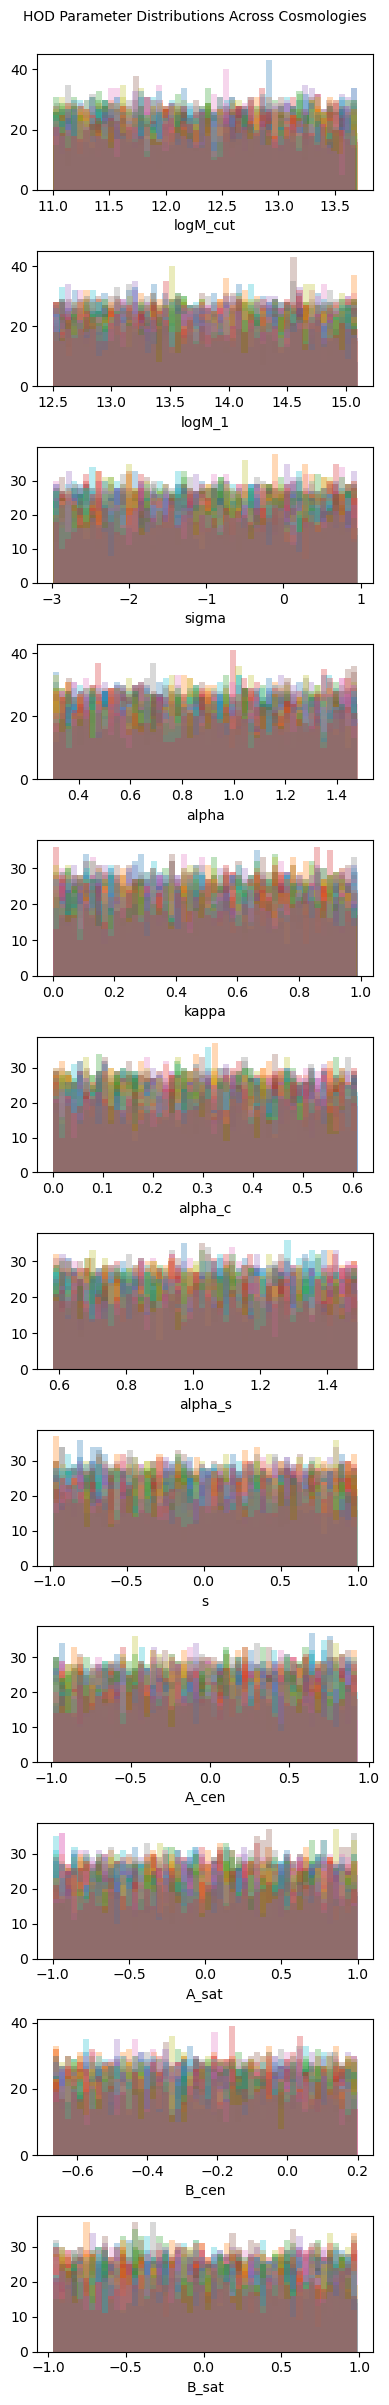

In [9]:
hod_params_cosmo = load_hod_params(str(parameters_dir / 'hod_params'))
hod_params_cosmo = [hod_params_cosmo[f'Bouchard25_c{c:03d}'] for c in sorted(cosmo_list)]

fig, ax = plot_hod_histogram(
    hods = hod_params_cosmo, 
    parameters = hod_params_cosmo[0].dtype.names, 
    labels = [f'c{c:03d}' for c in sorted(cosmo_list)],
    bins = 50, 
    alpha = 0.3, 
    # density = True,
)
# ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title='Cosmology')
fig.suptitle('HOD Parameter Distributions Across Cosmologies', fontsize=10, y=1.00)
fig.tight_layout()

#### Check Cosmological parameters

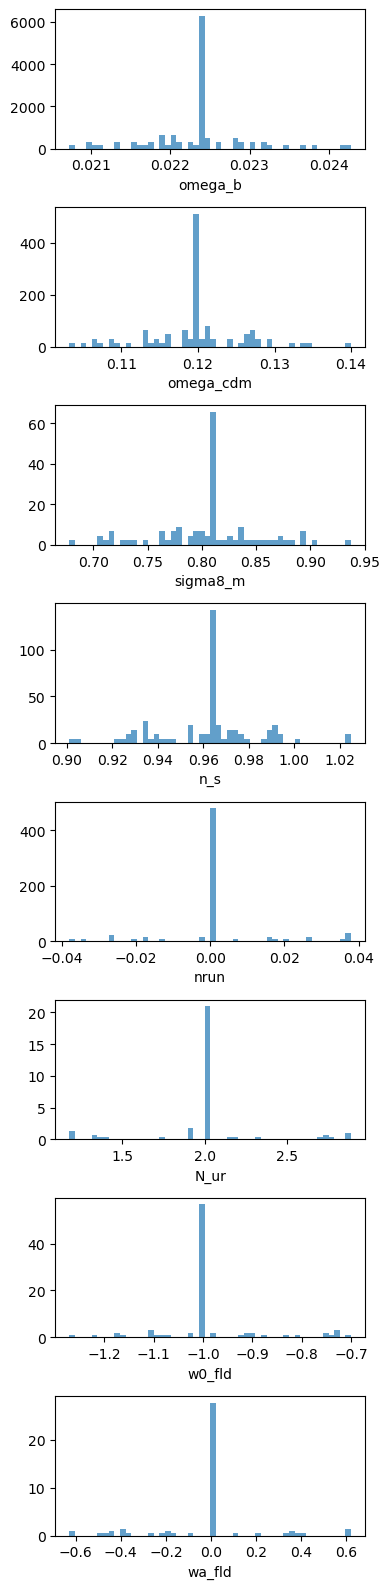

In [10]:
cosmo_params = load_hod_params(str(parameters_dir / 'cosmo+hod_params'))
cosmo_params = np.concatenate([cosmo_params[key] for key in sorted(cosmo_params.keys())])

fig, ax = plot_hod_histogram(
    hods = [cosmo_params], 
    parameters=cosmo_params.dtype.names[:8], 
    bins=50, 
    alpha=0.7, 
    density=True
)
fig.tight_layout()

#### Plot all c000 HOD parameters vs HOD parameters returning nbar=0.0085 for c000

Imposing a physical constraint on the sampled HOD space through a density cut.

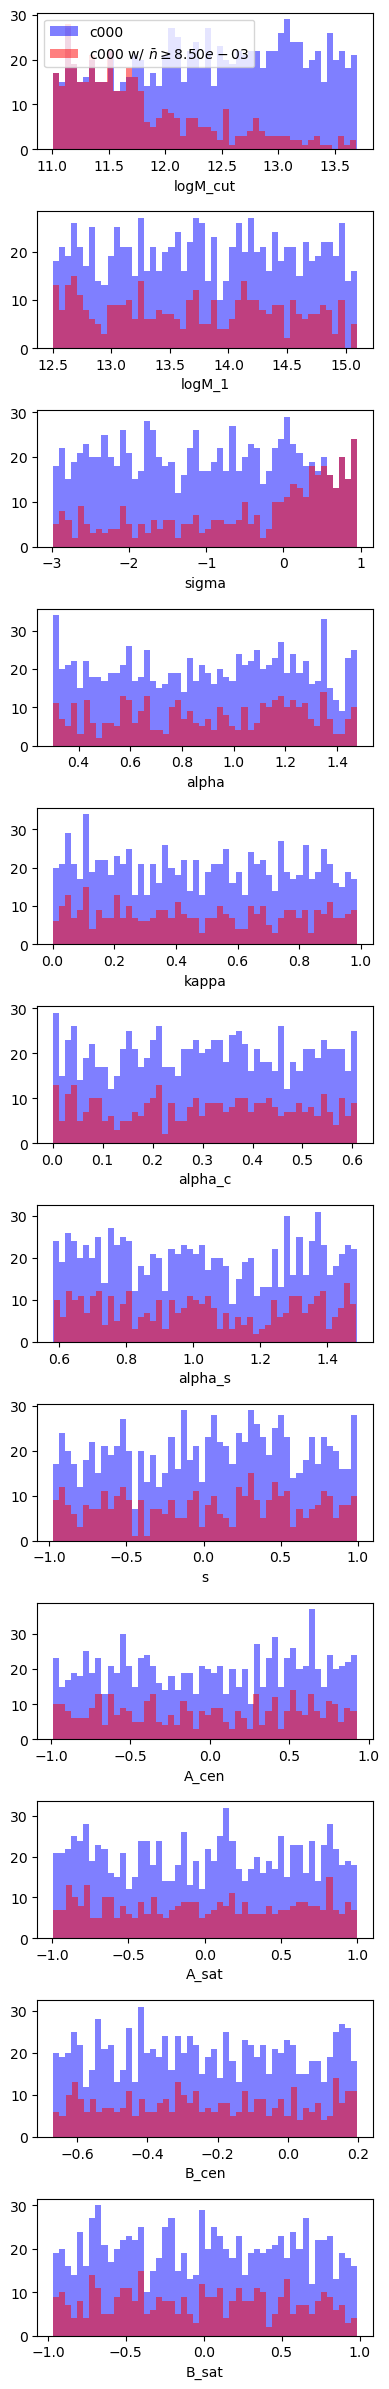

In [4]:
density_dir = bgs_nofilter_dir
density_fns = sorted(density_dir.glob('hod*/density.npy'))
densities = [np.load(fn) for fn in density_fns]
target_density = 8.5e-3 # Mpc^-3 h^3
density_idx = [int(fn.stem.lstrip('hod')) for i, fn in enumerate(sorted(density_dir.glob('hod*'))) if densities[i] >= target_density]

keys = [f'c{c:03d}' for c in sorted(cosmo_list)]
hod_params_c000 = load_hod_params(parameters_dir / 'hod_params', keys=keys)['c000']
hod_params_density = hod_params_c000[density_idx]

fig, ax = plot_hod_histogram(
    hods = [hod_params_c000, hod_params_density], 
    parameters = hod_params_c000.dtype.names, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

5


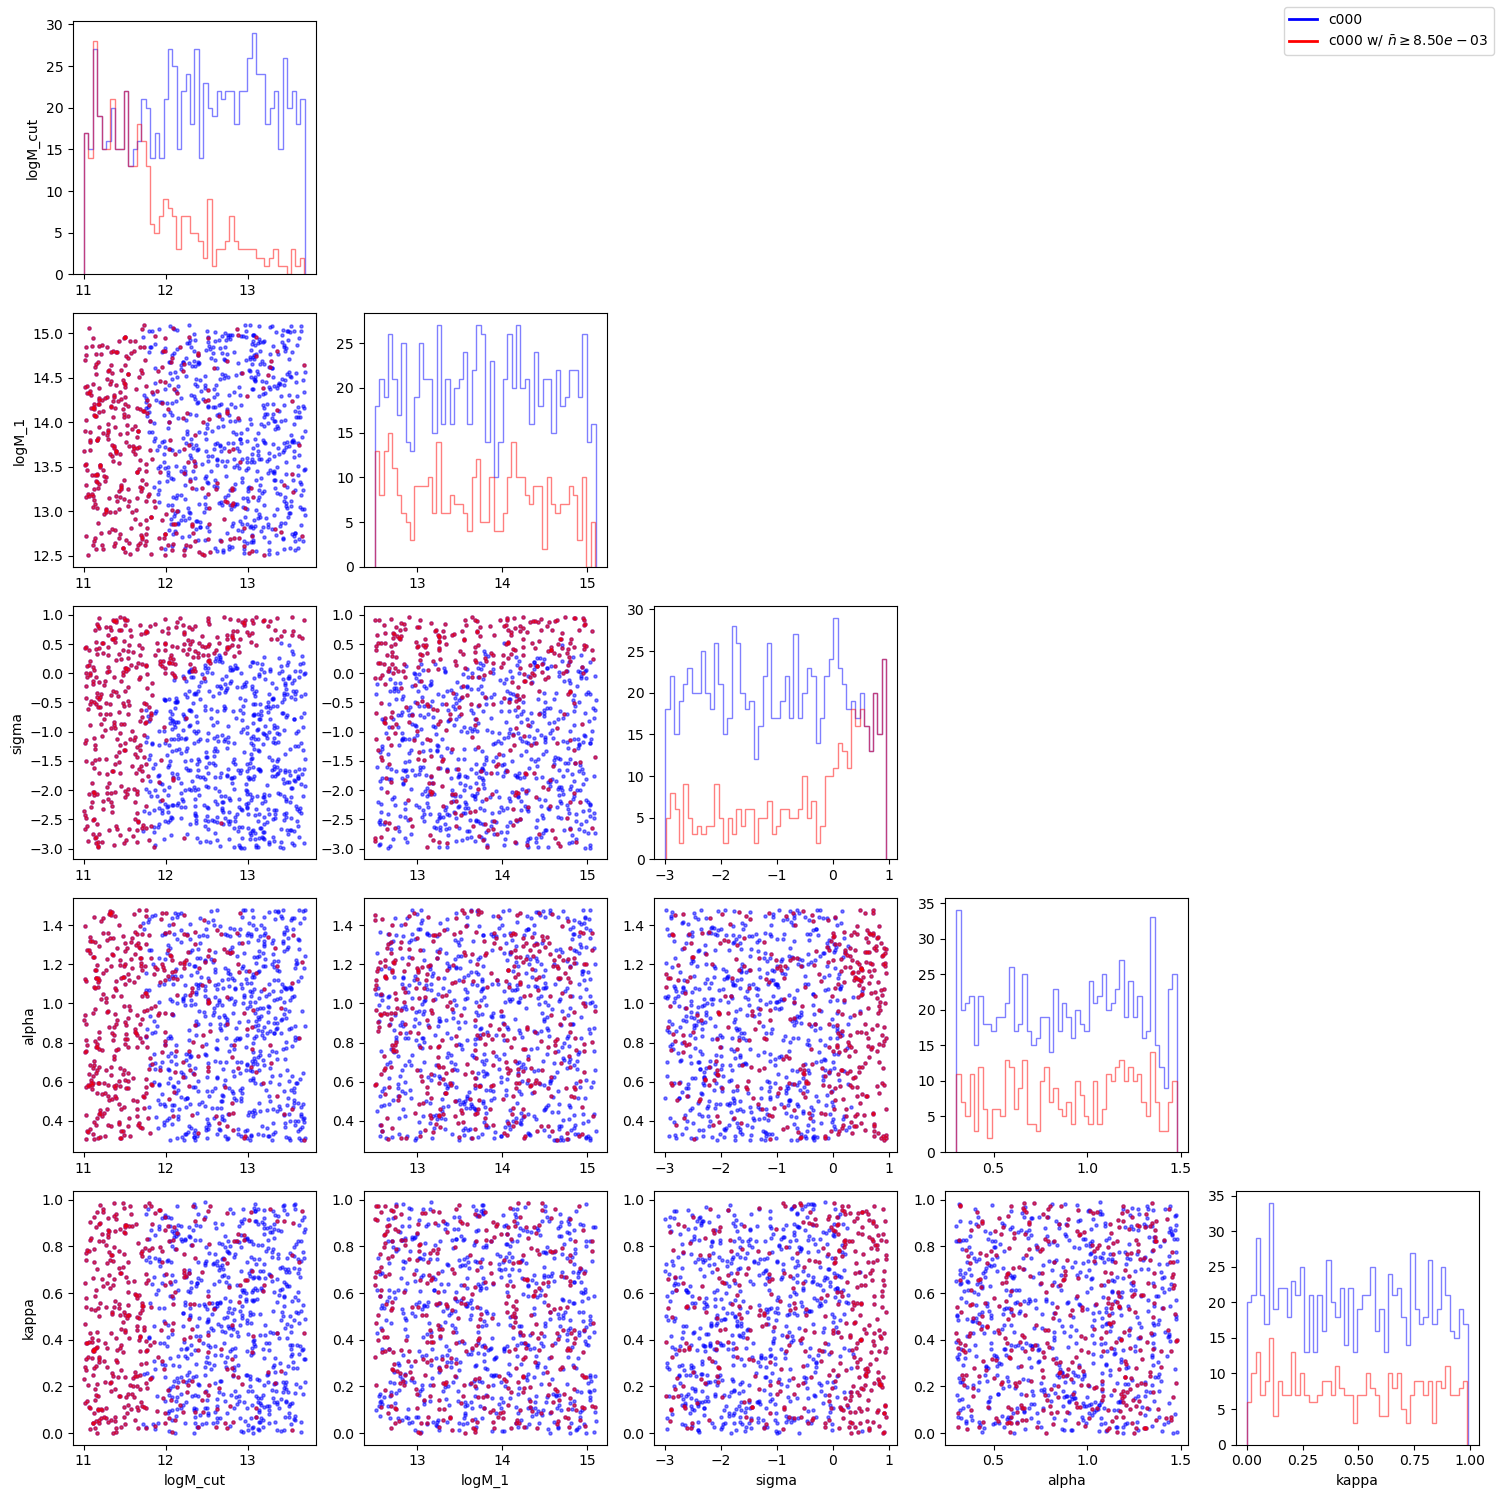

In [5]:
# triangle version
params = ['logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa']

fig, ax = plot_hod_triangle(
    hods = [hod_params_c000, hod_params_density], 
    parameters = params, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    s=5,
)
fig.tight_layout()

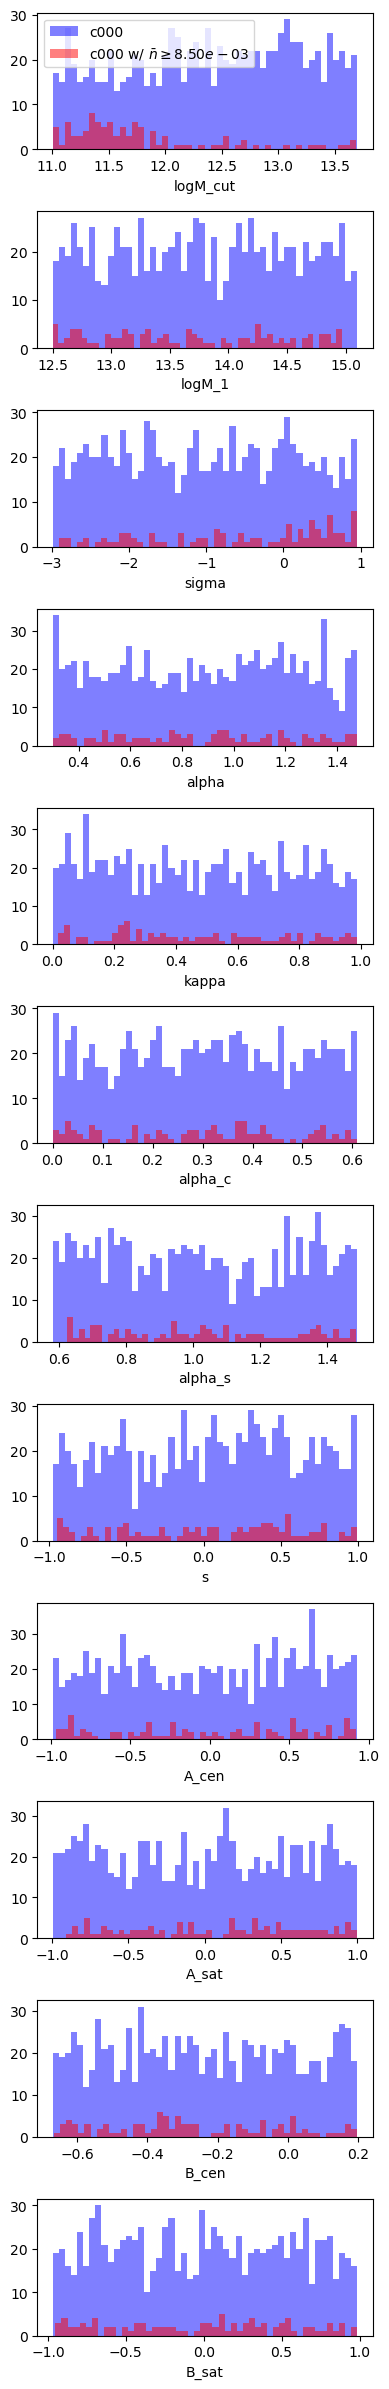

In [12]:
# TODO : remove limit to c000
hod_fns = sorted(measurements_dir.glob('base/c000_ph000/seed0/hod*'))
density_idx = [int(fn.stem.lstrip('hod')) for fn in hod_fns]
target_density = 8.5e-3 # Mpc^-3 h^3

hod_params_c000 = load_hod_params(parameters_dir / 'hod_params')['Bouchard25_c000']
hod_params_density = hod_params_c000[density_idx]

fig, ax = plot_hod_histogram(
    hods = [hod_params_c000, hod_params_density], 
    parameters = hod_params_c000.dtype.names, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

## 2- Processed mocks

Count the number of HOD folders in each cosmology folder.

Then, count the number of statistic files computed (marginalized over HOD) for each cosmology.

In [5]:
def get_hod_folders(dir: Path, cosmologies: list[int], phases: list[int], seeds: list[int], sim_type: str) -> dict:
    hod_fns = {}
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                f = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                fn_list = sorted(f.glob('hod*'))
                hod_fns[(cosmology, phase, seed)] = fn_list
    return hod_fns

#### Base boxes hod counts

In [8]:
hod_fns = get_hod_folders(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

expected_number = 100
warn_empty = False

for cosmology in cosmo_list:
    count = len(hod_fns[(cosmology, 0, 0)])
    if count <= expected_number and count > 0:
        last_hod = hod_fns[(cosmology, 0, 0)][-1].stem.lstrip('hod')
        print(f'Cosmology c{cosmology:03d} has {count} HOD folders (expected {expected_number}). Last HOD: {last_hod}')
    elif count == 0 and warn_empty:
        print(f'Cosmology c{cosmology:03d} has no HOD folders.')

Cosmology c000 has 100 HOD folders (expected 100). Last HOD: 279


In [10]:
statistics = [
    'density',
    'tpcf_los_x',
    'tpcf_los_y',
    'tpcf_los_z',
    'quantile_data_correlation_los_x',
    'quantile_data_correlation_los_y',
    'quantile_data_correlation_los_z',
    'quantile_correlation_los_x',
    'quantile_correlation_los_y',
    'quantile_correlation_los_z',
]
expected_number = 100
warn_empty = False

stat_count = {statistic: {} for statistic in statistics}

for cosmology in cosmo_list:
    for statistic in statistics:
        count = 0
        for fn in hod_fns[(cosmology, 0, 0)]:
                stat_fns = sorted(fn.glob(f'{statistic}*.npy'))
                count += len(stat_fns)
        
        stat_count[statistic][cosmology] = count
        if count <= expected_number and count > 0:
            print(f'Cosmology c{cosmology:03d} has {count} {statistic} files (expected {expected_number}).')
        elif count == 0 and warn_empty:
            # print(f'Cosmology c{cosmology:03d} has no {statistic} files.')
            pass

Cosmology c000 has 100 density files (expected 100).
Cosmology c000 has 100 tpcf_los_x files (expected 100).
Cosmology c000 has 100 tpcf_los_y files (expected 100).
Cosmology c000 has 100 tpcf_los_z files (expected 100).
Cosmology c000 has 100 quantile_data_correlation_los_x files (expected 100).
Cosmology c000 has 100 quantile_data_correlation_los_y files (expected 100).
Cosmology c000 has 100 quantile_data_correlation_los_z files (expected 100).
Cosmology c000 has 100 quantile_correlation_los_x files (expected 100).
Cosmology c000 has 100 quantile_correlation_los_y files (expected 100).
Cosmology c000 has 100 quantile_correlation_los_z files (expected 100).


## 3- Measurements

### 3.1- Density

In [11]:
def get_densities(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get densities from all the HOD realizations."""
    densities = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                fn_list = (Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}').glob('hod*/density.npy')
                for fn in fn_list:
                    d = np.load(fn, allow_pickle=True).item()
                    densities.append(d)
    densities = np.array(densities)
    return densities

#### Base boxes density histogram

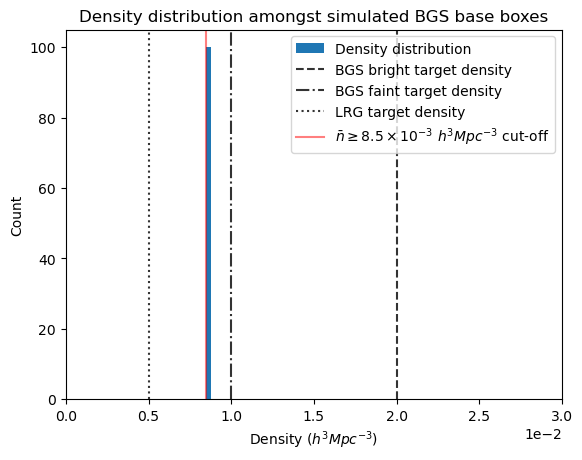

In [12]:
densities = get_densities(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

bins = np.linspace(0, 0.03, 100)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.5, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS base boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

#### Small boxes density histogram

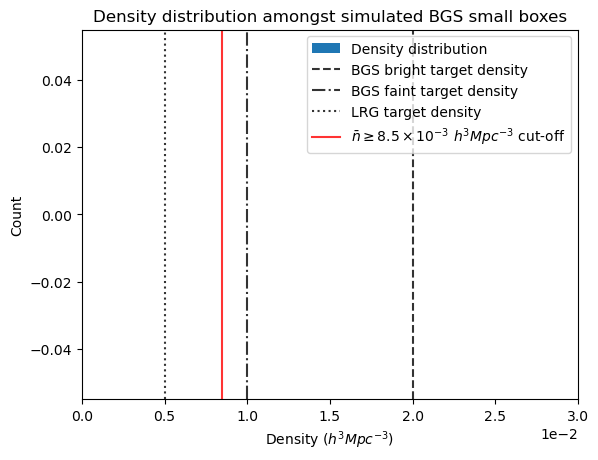

In [13]:
densities = get_densities(dir=measurements_dir, cosmologies=[0], phases=[0], seeds=[0], sim_type='small')

bins = np.linspace(0, 0.03, 50)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.8, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS small boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

### 3.2- Two-point correlation function

In [4]:
from pycorr import TwoPointEstimator
def get_tpcf(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get two-point correlation functions from all the HOD realizations."""
    tpcfs = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                dir_ = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                # Get all the HOD realizations
                hod_folders = sorted(dir_.glob('hod*'))
                for hod in hod_folders:
                    fn_list = sorted(hod.glob('tpcf_los_*.npy'))
                    tmp_cf = None
                    for fn in fn_list:
                        d = TwoPointEstimator.load(fn)
                        if tmp_cf is None:
                            tmp_cf = d
                        else:
                            tmp_cf = d.concatenate_x(d, tmp_cf)
                    if tmp_cf is not None:
                        tpcfs.append(tmp_cf)
    tpcfs = np.array(tpcfs)
    return tpcfs

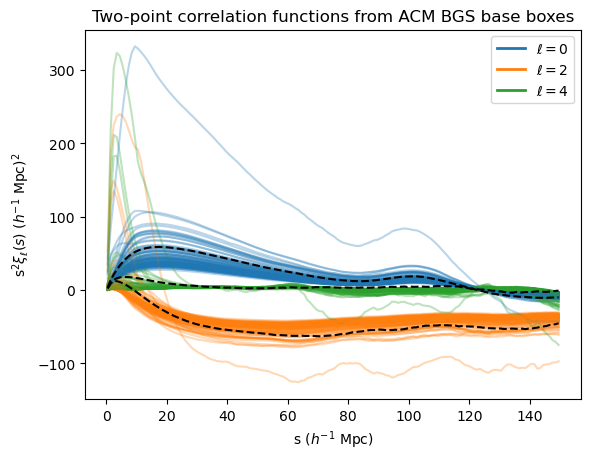

In [11]:
cfs = get_tpcf(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

ells = [0, 2, 4]
for cf in cfs:
    s, poles = cf(ells=ells, return_sep=True)
    for i, p in enumerate(ells):
            plt.plot(s, poles[i]*s**2, alpha=0.3, c=f'C{i}')

handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=rf'$\ell={{{i*2}}}$') for i in range(3)
]
plt.legend(handles=handles)

plt.xlabel(r's ($h^{-1}$ Mpc)')
plt.ylabel(r's$^2 \xi_{\ell}(s)$ ($h^{-1}$ Mpc)$^2$')
plt.title('Two-point correlation functions from ACM BGS base boxes');

sg_cf = None
for fn in sorted(sg_dir.glob('tpcf_los_*.npy')):
    cf = TwoPointEstimator.load(fn)
    if sg_cf is None:
        sg_cf = cf
    else:
        sg_cf = sg_cf.concatenate_x(sg_cf, cf)

s, poles = sg_cf(ells=ells, return_sep=True)
for i, p in enumerate(ells):
    plt.plot(s, poles[i]*s**2, alpha=1.0, c=f'k', ls='--')
    
# plt.ylim(-100, 100);
# plt.xlim(0, 30);

### 3.3- Density split

In [16]:
def get_ds_cf(stat_name: str, dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str, quantiles: list = [0,1,3,4]) -> np.ndarray:
    """Get DensitySplit correlation functions from all the HOD realizations."""
    ds_cfs = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                dir_ = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                # Get all the HOD realizations
                hod_folders = sorted(dir_.glob('hod*'))
                for hod in hod_folders:
                    fn_list = sorted(hod.glob(f'{stat_name}_los_*.npy'))
                    tmp_cf = None
                    for fn in fn_list:
                        d = np.load(fn, allow_pickle=True)[quantiles]
                        if tmp_cf is None:
                            tmp_cf = d
                        else:
                            tmp_cf = [q.concatenate_x(q, tmp_cf[i]) for i, q in enumerate(d)]
                    if tmp_cf is not None:
                        ds_cfs.append(tmp_cf)
    ds_cfs = np.array(ds_cfs)
    return ds_cfs

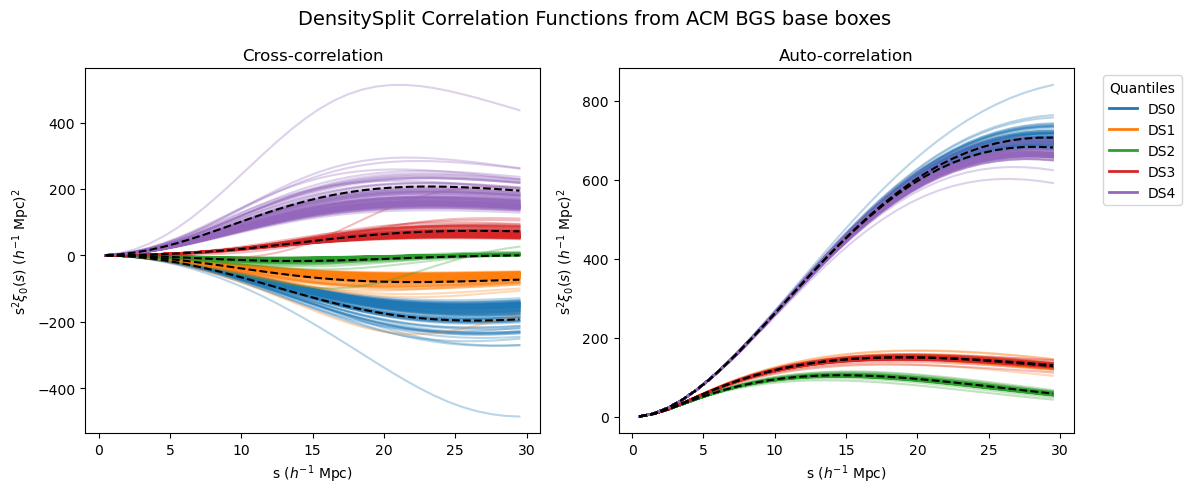

In [17]:
quantiles = [0, 1, 2, 3, 4] 
cc_cfs = get_ds_cf(stat_name='quantile_data_correlation', dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base', quantiles=quantiles)
ac_cfs = get_ds_cf(stat_name='quantile_correlation', dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base', quantiles=quantiles)

fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)

ell = 0
for i, q in enumerate(quantiles):
    for cf in cc_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[0].plot(s, poles[0]*s**2, alpha=0.3, c=f'C{i}')
    for cf in ac_cfs:
        s, poles = cf[i](ells=[ell], return_sep=True)
        ax[1].plot(s, poles[0]*s**2, alpha=0.3, c=f'C{i}')
        
handles = [
    plt.Line2D([0], [0], color=f'C{i}', lw=2, label=f'DS{q}') for i, q in enumerate(quantiles)
]
ax[1].legend(handles=handles, title='Quantiles', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[0].set_title('Cross-correlation')
ax[1].set_title('Auto-correlation')

for a in ax:
    a.set_xlabel(r's ($h^{-1}$ Mpc)')
    a.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')

fig.suptitle('DensitySplit Correlation Functions from ACM BGS base boxes', fontsize=14)
fig.tight_layout()

fn_list_cc = sorted(sg_dir.glob('quantile_data_correlation_los_*.npy'))
fn_list_ac = sorted(sg_dir.glob('quantile_correlation_los_*.npy'))
ccf = None
acf = None
for fn in fn_list_cc:
    d = np.load(fn, allow_pickle=True)[quantiles]
    if ccf is None:
        ccf = d
    else:
        ccf = [q.concatenate_x(q, ccf[i]) for i, q in enumerate(d)]
for fn in fn_list_ac:
    d = np.load(fn, allow_pickle=True)[quantiles]
    if acf is None:
        acf = d
    else:
        acf = [q.concatenate_x(q, acf[i]) for i, q in enumerate(d)]

for i, q in enumerate(quantiles):
    s, poles = ccf[i](ells=[ell], return_sep=True)
    ax[0].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

    s, poles = acf[i](ells=[ell], return_sep=True)
    ax[1].plot(s, poles[0]*s**2, alpha=1.0, c=f'k', ls='--')

### 3.4- Interactive visualization of the measurements

In [ ]:
from matplotlib.widgets import Button, Slider
%matplotlib widget

hod_idx_fns = get_hod_folders(dir=measurements_dir, cosmologies=[0], phases=[0], seeds=[0], sim_type='base')
hod_idx = [int(f.stem.split('hod')[-1]) for f in hod_idx_fns[(0,0,0)]]
cfs = get_tpcf(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

fig, ax = plt.subplots()
s, poles = cfs[0](ells=[0], return_sep=True)
line = ax.plot(s, poles[0]*s**2, alpha=1.0, c='k')
ax.set_xlabel(r's ($h^{-1}$ Mpc)')
ax.set_ylabel(r's$^2 \xi_{0}(s)$ ($h^{-1}$ Mpc)$^2$')
ax.set_title(f'Two-point correlation function for HOD {hod_idx[0]}');

slider_ax = fig.add_axes([0.25, 0.1, 0.65, 0.03])
hod_slider = Slider(
    ax=slider_ax,
    label='HOD Index',
    valmin=hod_idx[0],
    valmax=hod_idx[-1],
    valinit=hod_idx[0],
    valstep=1,
    orientation='horizontal'
)

def plot_hod(idx: int):
    idx = int(idx)
    if idx not in hod_idx:
        return
    idx = hod_idx.index(idx)
    hod = hod_idx[idx]
    s, poles = cfs[idx](ells=[0], return_sep=True)
    line[0].set_ydata(poles[0]*s**2)
    ax.relim()
    ax.autoscale_view()
    ax.set_title(f'Two-point correlation function for HOD {hod}')
    fig.canvas.draw_idle()

hod_slider.on_changed(plot_hod)
resetax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', hovercolor='0.975')
def reset(event):
    hod_slider.reset()
button.on_clicked(reset)

In [8]:
plt.close()

## 4- Best-fit HOD comparison
*See `--plot` option from `best_fit.py` to get this figure.*

<img src="best_fit_c000_ells(0, 2).png" alt="Best-fit HOD comparison figure" width="600"/>

## 5- Compressed files